# Getting Global Warming Rates

Easier to do this with xarray than in R. Objective is simple, process full global timeline to table of global temperature and anomalies. Use that table to get global warming rates for the temperature report.

In [ ]:
# Libraries
import requests
import os
import xarray as xr
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import oisstools as ot

# Set the workspace - local/ docker
box_root = ot.set_workspace("local")
box_root = box_root.replace("akemberling", "adamkemberling")

# Set the climatology period
reference_period = "1991to2020"

# Set climatology source choices
climatologies = {
    "1982to2011" : "1982to2011_climatology",
    "1991to2020" : "1991to2020_climatology"}

climate_period = climatologies[reference_period]

# document what choices were made on last run:
print(f"Working via directory at: {box_root}")
print(f"Calculating Anomalies for {reference_period} reference period using {climate_period}")

# Set a start and end period so we can play around:
start_yr = 1981
end_yr   = 2025

Working via directory at: /Users/adamkemberling/Library/CloudStorage/Box-Box/
Calculating Anomalies for 1991to2020 reference period using 1991to2020_climatology


## Load Global OISST, Dailt Climatology, and Anomalies

The following code will compute a complete sst history for the available OISST dataset including the average SST, the 30-year climatological average for that day of year, and the corresponding sst anomaly. This will be done using the raw data an area-weighting adjusted version to demonstrate the importance of correcting for cell-size differences.

### Get Mean Time Series, and Area-Weighted Series

Once the data is loaded to get the mean temperature or temperature anomaly across the lat lon dimensions.

For the global temperatures the size variation in grid cells moving poleward can distort overall temperatures. The following `ot.area_weighted_means` function will weight each cell by their relative 2-D physical areas.

In [56]:
# Load OISSt using ot.load_box_oisst()
oisst = ot.load_box_oisst(
    box_root, 
    start_yr, 
    end_yr, 
    anomalies = False, 
    do_parallel = True)

# Add MOD so we can join to climatology
oisst = ot.add_mod(oisst, 'time')

# Climatology
oisst_clim = ot.load_oisst_climatology(
    box_root = box_root, 
    reference_period = reference_period)

## Timeline for global anomalies
mean_temps = oisst.mean(['lat', 'lon']) 
mean_clim = oisst_clim.mean(["lat", "lon"])
  
# Area Weighted Means
area_wtd_means = ot.area_weighted_means(oisst, var_name = "sst", sd = False)
weighted_clim = ot.area_weighted_means(oisst_clim, var_name = "sst", sd = False)

# Close the dataset
oisst.close()
oisst_clim.close()

In [ ]:
# Load OISSt using ot.load_box_oisst()
oisst_anomalies = ot.load_box_oisst(
    box_root, 
    start_yr, 
    end_yr, 
    anomalies = True, 
    do_parallel = True,
    reference_period = climate_period)

# Timeline for global anomalies
mean_anomalies = oisst_anomalies.mean(['lat', 'lon']) 

# Get area-weighted means
weighted_anoms = ot.area_weighted_means(oisst_anomalies, var_name = "sst", sd = False)

# Close the dataset
oisst_anomalies.close()

##  Converting to Dataframes for Export

The next chunk drops the columns we don't need and joins the two time series into a single table for exporting it out.

In [ ]:
# Convert sst to a dataframe from xr.array
sst_df = mean_temps.sst.to_dataframe().rename(columns = {"sst" : "unweighted_sst"})
sst_wtd = area_wtd_means.area_wtd_sst.to_dataframe().rename(columns = {"area_wtd_sst": "area_weighted_sst"}).drop(columns = ["MOD"])

# Combine weighted and unweighted ssts
combined_sst = sst_df.join(sst_wtd).reset_index()
#combined_sst.tail()

# Combine weighted and unweighted climatologies
clim_df = mean_clim.to_dataframe().rename(columns = {"sst" : "unweighted_clim"})
clim_wtd_df = weighted_clim.to_dataframe().rename(columns = {"area_wtd_sst": "area_weighted_clim"})
combined_clim = clim_df.join(clim_wtd_df).reset_index().rename(columns = {"modified_ordinal_day" : "MOD"})

# Combine SSTs and Climatology information
sst_and_clim = combined_sst.merge(combined_clim, how = "left", on = "MOD")
sst_and_clim.head()

,time,MOD,unweighted_sst,area_weighted_sst,unweighted_clim,area_weighted_clim
0,1981-09-01,245,13.792295,18.088293,14.006861,18.335644
1,1981-09-02,246,13.778812,18.078184,14.005817,18.334883
2,1981-09-03,247,13.771966,18.072243,14.002554,18.332544
3,1981-09-04,248,13.761696,18.066229,13.998383,18.330311
4,1981-09-05,249,13.745052,18.054375,13.992052,18.325956


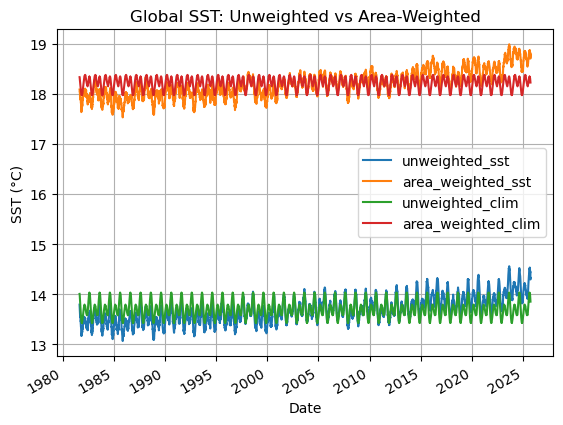

In [62]:
# Plot sst and area_wtd_sst together
sst_and_clim.set_index("time").drop(columns="MOD").plot()
plt.legend()
plt.title("Global SST: Unweighted vs Area-Weighted")
plt.ylabel("SST (°C)")
plt.xlabel("Date")
plt.grid()
plt.show()  

In [ ]:
# Convert area-weighted anomalies to dataframe
anom_df = mean_anomalies.sst.to_dataframe().rename(columns = {"sst" : "unweighted_sst_anom"})
anoms_wtd = weighted_anoms.area_wtd_sst.to_dataframe().rename(columns = {"area_wtd_sst" : "area_weighted_sst_anom"})

# Drop columns we don't need
anom_df = anom_df.drop(columns = ["MOD", "modified_ordinal_day"])
anoms_wtd  = anoms_wtd.drop(columns = ["MOD", "modified_ordinal_day"])

# Join
combined_anoms = anom_df.join(anoms_wtd).reset_index()

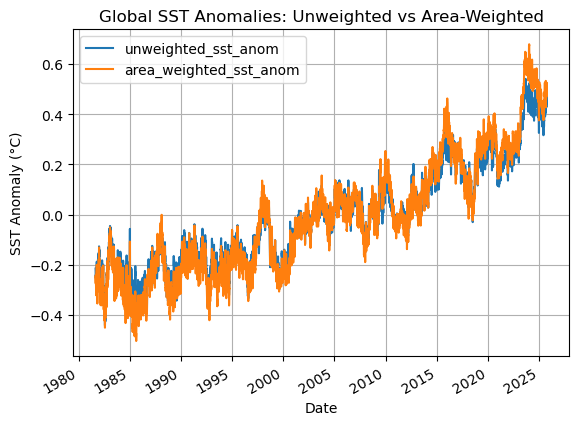

In [ ]:
# Plot sst and area_wtd_sst together
combined_anoms.set_index("time").plot()
plt.legend()
plt.title("Global SST Anomalies: Unweighted vs Area-Weighted")
plt.ylabel("SST Anomaly (°C)")
plt.xlabel("Date")
plt.grid()
plt.show()  

In [63]:
# Join the anomalies with the sst and climatology
temp_and_anom = sst_and_clim.merge(combined_anoms, how = "left", on = "time")
temp_and_anom.head()

,time,MOD,unweighted_sst,area_weighted_sst,unweighted_clim,area_weighted_clim,unweighted_sst_anom,area_weighted_sst_anom
0,1981-09-01,245,13.792295,18.088293,14.006861,18.335644,-0.214565,-0.247380
1,1981-09-02,246,13.778812,18.078184,14.005817,18.334883,-0.226999,-0.256714
2,1981-09-03,247,13.771966,18.072243,14.002554,18.332544,-0.230583,-0.260341
3,1981-09-04,248,13.761696,18.066229,13.998383,18.330311,-0.236684,-0.264091
4,1981-09-05,249,13.745052,18.054375,13.992052,18.325956,-0.246998,-0.271608


## Save!

In [64]:
# SAVING
sst_and_clim.to_csv(f"{box_root}Res_Data/OISST/oisst_mainstays/global_timeseries/global_temps_oisst.csv")
temp_and_anom.to_csv(f"{box_root}Res_Data/OISST/oisst_mainstays/global_timeseries/global_anoms_{reference_period}.csv")

---

## Old Approach

I originally had done the joining and renaming differentlt, but later went back to refactor to be consistent with ot.update_global_timeseries

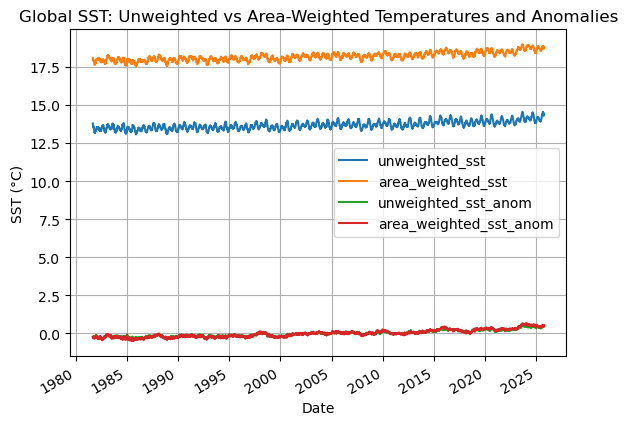

In [9]:
# # Join the Temperatures and Anomalies
# temp_and_anom = combined_sst.join(combined_anoms)
# temp_and_anom.plot()
# plt.legend()
# plt.title("Global SST: Unweighted vs Area-Weighted Temperatures and Anomalies")
# plt.ylabel("SST (°C)")
# plt.xlabel("Date")
# plt.grid()
# plt.show()  

In [ ]:
# Original approach, notice the join suffixes

#combined_sst = sst_df.join(sst_wtd, lsuffix = "_unwtd", rsuffix = "_wtd")
# # Rename the columns
# combined_sst = combined_sst.rename(columns = {"sst": "unweighted_sst", "area_wtd_sst": "area_weighted_sst"})
# combined_sst.tail()

#   # Join anomalies
#   anom_join = anom_df.merge(anom_wt_df, how = "left", on = ["time", "MOD"])
#   anom_join = anom_join.rename(columns = {"sst" : "sst_anom", f"area_wtd_sst" : "area_wtd_anom"})

#   # Join to the SST and Climatology dataframe to consolidate the update
#   update_ts = sst_and_clim.merge(anom_join, how = "left", on = ["time", "MOD"])


,MOD,unweighted_sst,area_weighted_sst
time,,,
2025-09-16 12:00:00,260,14.337382,18.737989
2025-09-17 12:00:00,261,14.346860,18.756187
2025-09-18 12:00:00,262,14.295133,18.707382
2025-09-19 12:00:00,263,14.325480,18.745930
2025-09-20 12:00:00,264,14.328765,18.751669
